In [1]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as kimage
from tensorflow.keras.models import load_model

In [2]:
# Download the dataset from kaggle
print("[INFO] Downloading dataset via kagglehub...")
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

# Directly point to the 'color' subfolder to get color images instead of grayscale images
DATA_DIR = os.path.join(path, "plantvillage dataset", "color")

# Check if the dataset is downloaded correctly
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Color folder not found at: {DATA_DIR}")

print(f"Data Directory set to: {DATA_DIR}")

# Configuration
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_FE  = 10   # Phase 1: Feature Extraction by training the classifier head only
EPOCHS_FT  = 10   # Phase 2: Fine-Tuning part of the model's layer and also classifier head together
SEED       = 42

# Setting the seed so that we can get the exact same training output across different devices
tf.random.set_seed(SEED)
np.random.seed(SEED)

[INFO] Downloading dataset via kagglehub...


100%|██████████| 2.04G/2.04G [01:38<00:00, 22.3MB/s]

Extracting files...


Data Directory set to: /Users/jinwei/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset/color


In [ ]:
# References for ImageDataGenerator: https://rosenfelder.ai/keras-regression-efficient-net/#code-overview
# Prepare data to be loaded into model easily
train_datagen = ImageDataGenerator(
    validation_split   = 0.2,
    preprocessing_function = preprocess_input,
    # apply several data augmentation techniques to improve model's ability to generalise
    rotation_range = 30,
    width_shift_range = 0.15,
    height_shift_range = 0.15,
    shear_range = 0.15,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = "nearest",
)

val_datagen = ImageDataGenerator(
    validation_split   = 0.2,
    preprocessing_function = preprocess_input,
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    subset = "training",
    seed = SEED,
    shuffle = True,
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = "categorical",
    subset = "validation",
    seed = SEED,
    shuffle = False,
)

NUM_CLASSES = train_gen.num_classes
CLASS_NAMES = list(train_gen.class_indices.keys())

print(f"\nNumber of classes: {NUM_CLASSES}")
print(f"Number of train samples: {train_gen.samples}")
print(f"Number of validation samples: {val_gen.samples}")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.

Number of classes: 38
Number of train samples: 43456
Number of validation samples: 10849


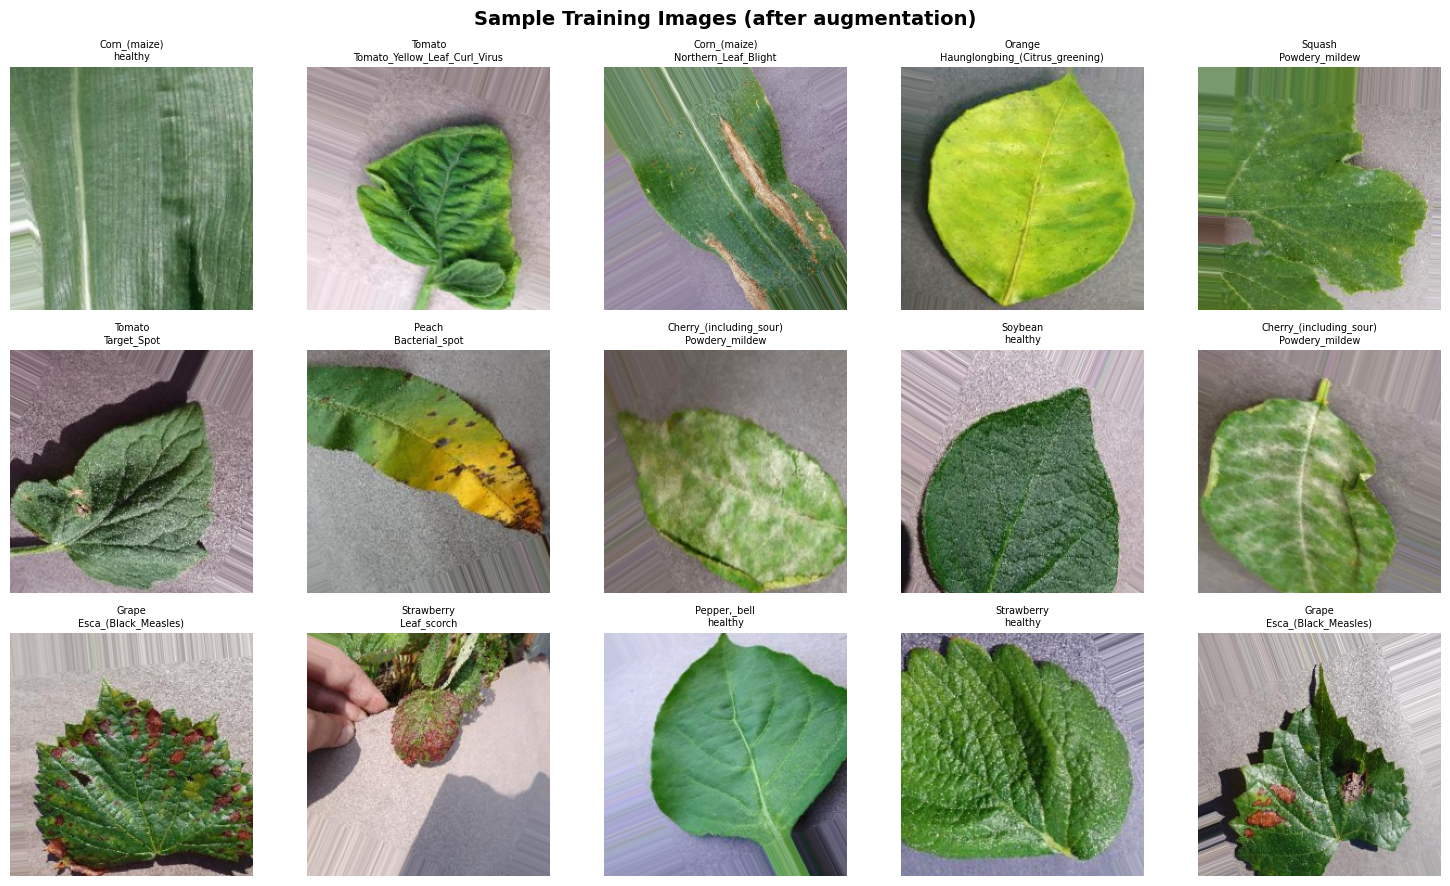

In [4]:
# Sample Images Visualisation
sample_imgs, sample_labels = next(train_gen)

# Normalise images back to [0,1] range so that it fits the matplotlib's format to display image
def deprocess(img):
    img = img - img.min()
    img = img / img.max()
    return img

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Sample Training Images (after augmentation)", fontsize=14, fontweight="bold")
for i, ax in enumerate(axes.flat):
    ax.imshow(deprocess(sample_imgs[i]))
    label_idx  = np.argmax(sample_labels[i])
    short_name = CLASS_NAMES[label_idx].replace("___", "\n").replace("__", " ")
    ax.set_title(short_name, fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# Transfer Learning
# We learn about finetuning a EfficientNet model from 
# https://python.plainenglish.io/revolutionizing-pharmaceutical-waste-management-with-ai-a-solution-built-with-tensorflow-bc08b31a7dbc
# We get the potential smaller version of custom classifier head from this article: https://doi.org/10.48550/arXiv.2604.12305, 
# since the classifier head is used in X-ray images in the article, we first try to use the same classifier head and the performance 
# is good so we did not make much changes to the head to avoid affecting the model's performance and training result. 
base_model = EfficientNetB0(
    weights     = "imagenet",
    include_top = False,
    input_shape = (*IMG_SIZE, 3),
)

# Frozen for training only the classifier head to let the model be familiar with the leaf features first
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.45),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,851,657 (18.51 MB)

 Trainable params: 799,526 (3.05 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [6]:
# Callbacks used during training loop
def get_callbacks(phase):
    return [
        callbacks.ModelCheckpoint(
            f"best_phase{phase}.keras",
            monitor="val_accuracy", save_best_only=True, verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor="val_accuracy", patience=5,
            restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-7, verbose=1,
        ),
    ]

In [ ]:
# Training the classifier head first, and this version of model will be saved as "best_phase1.keras"
# References for training method: 
# 1. https://keras.io/guides/training_with_built_in_methods/
# 2. https://keras.io/examples/vision/image_classification_efficientnet_fine_tuning/
print("\nPhase 1: Training classifier head (backbone frozen)...")

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = "categorical_crossentropy",
    metrics = ["accuracy"],
)

history1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 10,
    callbacks = get_callbacks(1),
)


Phase 1: Training classifier head (backbone frozen)...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6987 - loss: 1.0978
Epoch 1: val_accuracy improved from None to 0.90598, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 455s 333ms/step - accuracy: 0.7953 - loss: 0.7015 - val_accuracy: 0.9060 - val_loss: 0.2818 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.8702 - loss: 0.4177
Epoch 2: val_accuracy improved from 0.90598 to 0.92829, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 435s 320ms/step - accuracy: 0.8738 - loss: 0.4091 - val_accuracy: 0.9283 - val_loss: 0.2173 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.8944 - loss: 0.3419
Epoch 3: val_accuracy improved from 0.92829 to 0.94571, saving model to best_phase1.keras

Epoch 

In [ ]:
# Fine-Tuning last 30 layers of the backbone of original EfficientNet model
print("\nPhase 2: Fine-tuning top backbone layers...")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable backbone layers: {trainable} / {len(base_model.layers)}")

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5), # learning rate is smaller so that the model won't overfit
    loss = "categorical_crossentropy",
    metrics = ["accuracy"],
)

history2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 10,
    callbacks = get_callbacks(2),
)


Phase 2: Fine-tuning top backbone layers...
Trainable backbone layers: 30 / 238
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8501 - loss: 0.5395
Epoch 1: val_accuracy improved from None to 0.94340, saving model to best_phase2.keras

Epoch 1: finished saving model to best_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 530s 386ms/step - accuracy: 0.8734 - loss: 0.4459 - val_accuracy: 0.9434 - val_loss: 0.1742 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9105 - loss: 0.3067
Epoch 2: val_accuracy improved from 0.94340 to 0.95530, saving model to best_phase2.keras

Epoch 2: finished saving model to best_phase2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 520s 383ms/step - accuracy: 0.9154 - loss: 0.2880 - val_accuracy: 0.9553 - val_loss: 0.1353 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9259 - loss: 0.2533
Epoch 3: val_accuracy improved from 0.95530 to 0.95972, saving m

In [10]:
# The final model is saved
model.save("plant_disease_efficientnet.keras")
print("\nModel saved at plant_disease_efficientnet.keras")


Model saved at plant_disease_efficientnet.keras


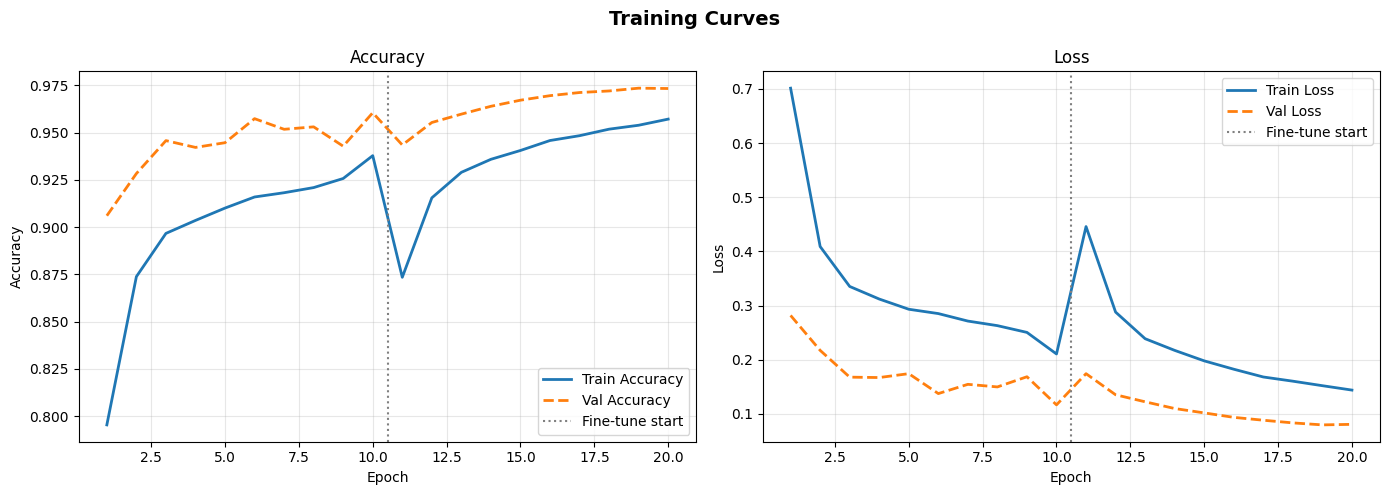

In [ ]:
# References: https://www.tensorflow.org/tutorials/images/transfer_learning#plot_learning_curves
# We will plot the learning curves to observe the model's training process
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_a = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss = history1.history["loss"] + history2.history["loss"]
val_l = history1.history["val_loss"] + history2.history["val_loss"]
ep = range(1, len(acc) + 1)
split = len(history1.history["accuracy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training Curves", fontsize=14, fontweight="bold")

for ax, tm, vm, title in [
    (ax1, acc,  val_a, "Accuracy"),
    (ax2, loss, val_l, "Loss"),
]:
    ax.plot(ep, tm, label=f"Train {title}", linewidth=2)
    ax.plot(ep, vm, label=f"Val {title}",   linewidth=2, linestyle="--")
    ax.axvline(split + 0.5, color="gray", linestyle=":", linewidth=1.5, label="Fine-tune start")
    ax.set_xlabel("Epoch"); ax.set_ylabel(title)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# We evaluate the model with validation set of images and also classification report
val_gen.reset()
loss_val, acc_val = model.evaluate(val_gen, verbose=1)
print(f"\nValidation Loss: {loss_val:.4f}")
print(f"Validation Accuracy: {acc_val * 100:.2f}%")

val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

print("\n── Classification Report ──────────────────────────────────")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

340/340 ━━━━━━━━━━━━━━━━━━━━ 86s 253ms/step - accuracy: 0.9735 - loss: 0.0796

Validation Loss: 0.0796
Validation Accuracy: 97.35%
340/340 ━━━━━━━━━━━━━━━━━━━━ 90s 264ms/step

── Classification Report ──────────────────────────────────
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.983     0.913     0.947       126
                                 Apple___Black_rot      0.992     0.992     0.992       124
                          Apple___Cedar_apple_rust      1.000     1.000     1.000        55
                                   Apple___healthy      0.976     0.985     0.980       329
                               Blueberry___healthy      0.993     1.000     0.997       300
          Cherry_(including_sour)___Powdery_mildew      1.000     0.995     0.998       210
                 Cherry_(including_sour)___healthy      0.988     0.982     0.985       170
Corn_(maize)___Cercospora_l

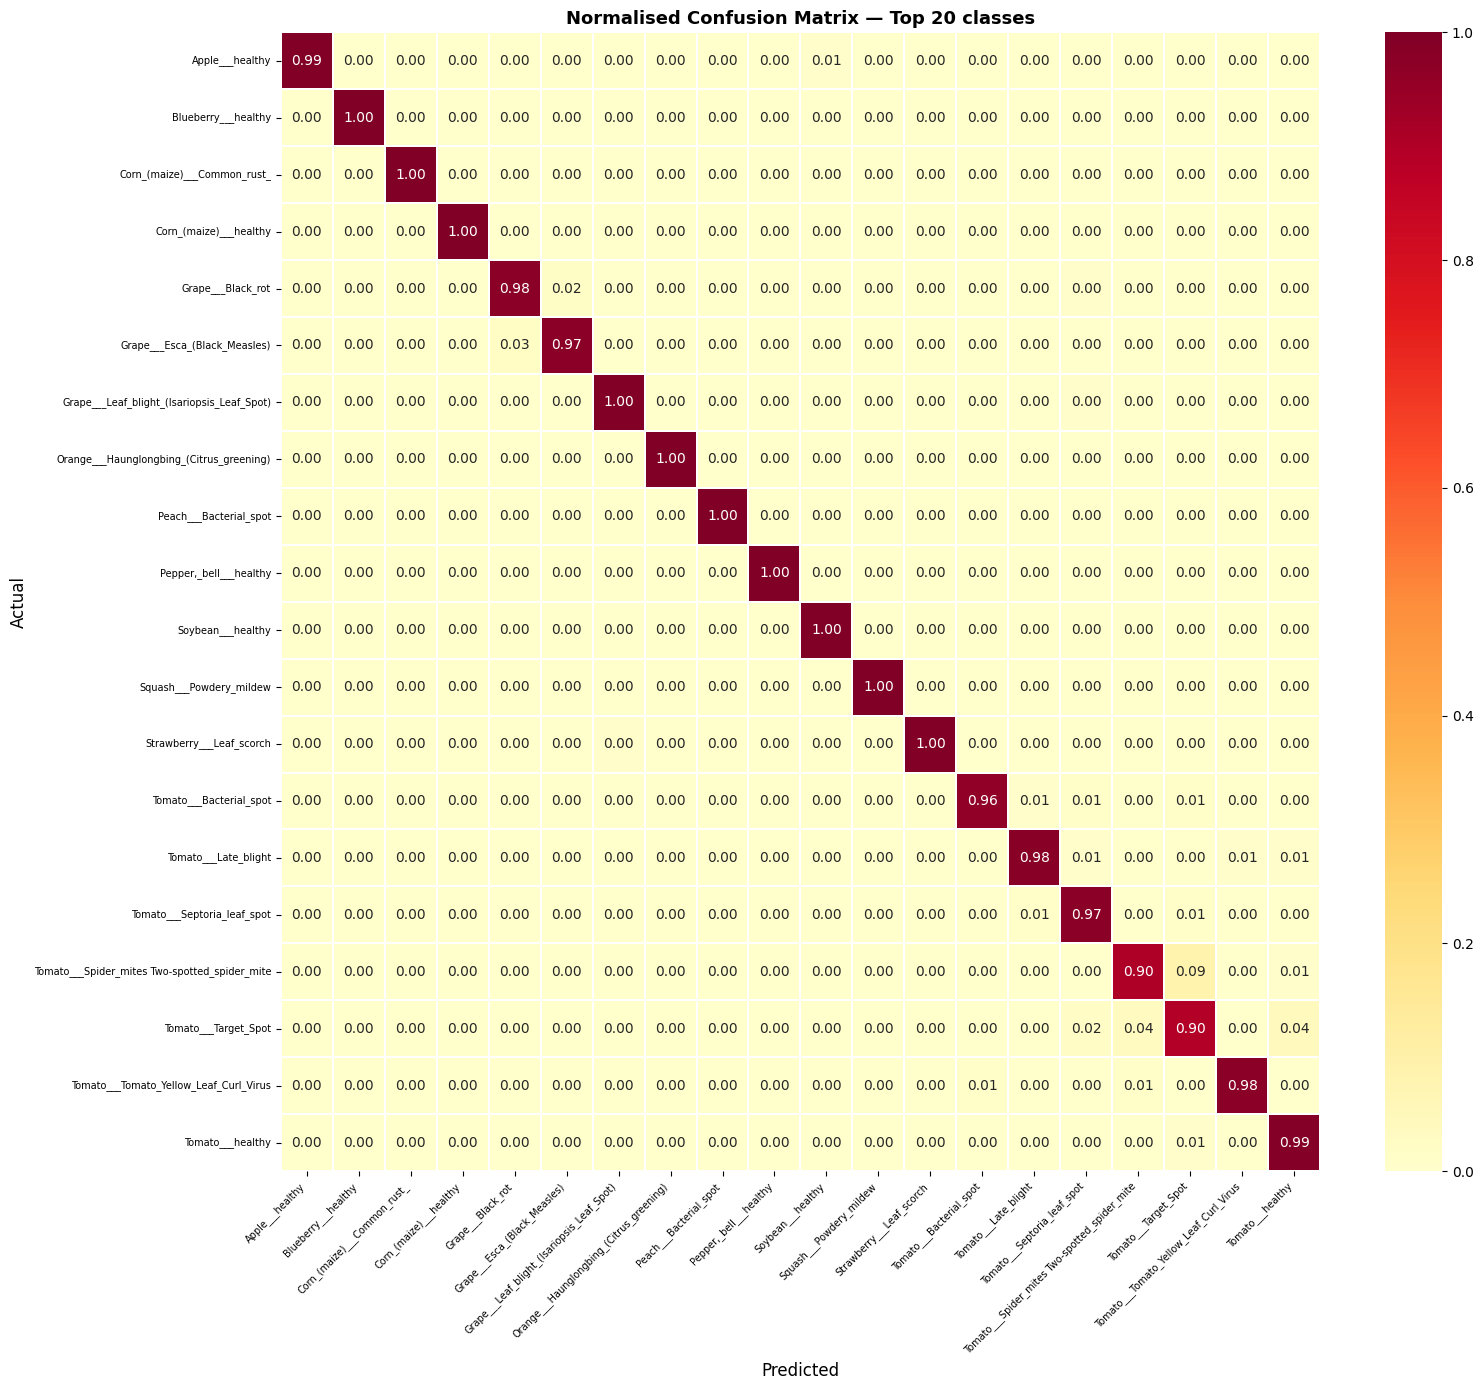

In [ ]:
# References for top 20 confusion matrix plotting: https://stackoverflow.com/questions/35272823/is-it-possible-to-plot-a-confusion-matrix-with-90-classes
# We plot a confusion matrix for the top 20 common classes appears in the validation dataset

top_classes_idx = [label[0] for label in Counter(y_true).most_common()[:20]]
top_classes_names = [CLASS_NAMES[i] for i in top_classes_idx] + ["_other"]

top_y_true_names = [CLASS_NAMES[y] if y in top_classes_idx else "_other" for y in y_true]
top_y_pred_names = [CLASS_NAMES[y] if y in top_classes_idx else "_other" for y in y_pred]

cm = confusion_matrix(top_y_true_names, top_y_pred_names, labels=top_classes_names)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=top_classes_names, yticklabels=top_classes_names,
    ax=ax, linewidths=0.3, linecolor="white",
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Normalised Confusion Matrix — Top 20 classes + _other",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

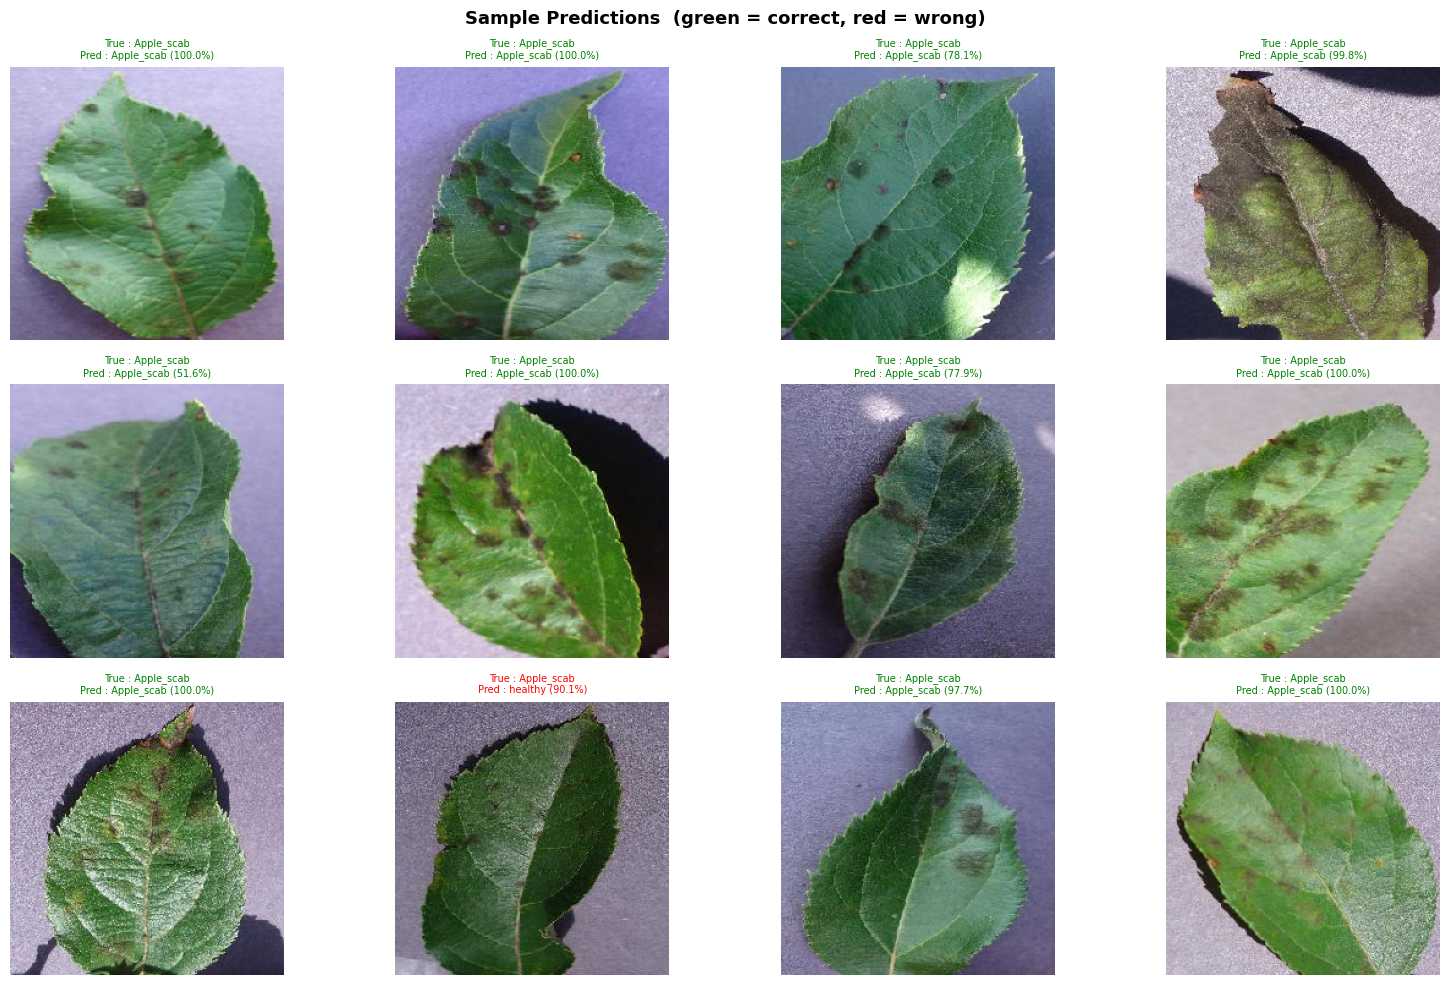

In [ ]:
# A series of prediction result is displayed
val_gen.reset()
imgs, true_labels = next(val_gen)
preds = model.predict(imgs[:12], verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("Sample Predictions  (green = correct, red = wrong)",
             fontsize=13, fontweight="bold")
for i, ax in enumerate(axes.flat):
    ax.imshow(deprocess(imgs[i]))
    true_name = CLASS_NAMES[np.argmax(true_labels[i])].split("___")[-1][:22]
    pred_name = CLASS_NAMES[np.argmax(preds[i])].split("___")[-1][:22]
    conf = np.max(preds[i]) * 100
    correct = np.argmax(true_labels[i]) == np.argmax(preds[i])
    ax.set_title(
        f"True : {true_name}\nPred : {pred_name} ({conf:.1f}%)",
        color="green" if correct else "red", fontsize=7,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

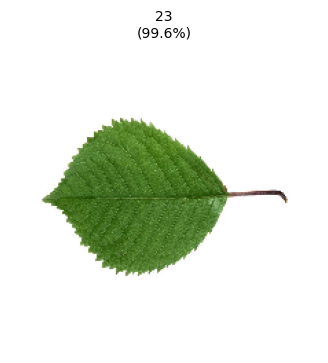

Top-5 predictions:
  Raspberry___healthy                                  99.64%
  Strawberry___healthy                                  0.30%
  Apple___healthy                                       0.03%
  Apple___Apple_scab                                    0.01%
  Cherry_(including_sour)___healthy                     0.01%


In [ ]:
# 13. SINGLE IMAGE PREDICTION
# Upload any leaf image and run this cell to get a prediction.

model = load_model("plant_disease_efficientnet.keras")
img_path = "img/Cherry Healthy 1.jpg"

img = kimage.load_img(img_path, target_size=(224, 224))
x = kimage.img_to_array(img)
x = preprocess_input(x)
x = np.expand_dims(x, axis=0)
probs = model.predict(x, verbose=0)[0]
top5 = probs.argsort()[-5:][::-1]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"{top5[0]}\n({probs[top5[0]]*100:.1f}%)", fontsize=10)
plt.show()

print("Top-5 predictions:")
for idx in top5:
    print(f"  {CLASS_NAMES[idx]:<50s}  {probs[idx]*100:6.2f}%")